In [1]:
import warnings
warnings.filterwarnings('ignore')

import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from glob import glob
from tqdm import tqdm


import tensorflow as tf
from tensorflow.keras.applications import DenseNet201, EfficientNetB7
from tensorflow.keras.applications.efficientnet import preprocess_input as preprocess_efficient
from tensorflow.keras.applications.resnet50 import preprocess_input as preprocess_resnet
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE
import xgboost as xgb
from sklearn.svm import SVC
import joblib
from PIL import Image, ImageFilter


In [2]:
DATA_DIR = "./natural_disaster_dataset"
TRAIN_DIR = os.path.join(DATA_DIR, "train")
VAL_DIR = os.path.join(DATA_DIR, "val")
TEST_DIR = os.path.join(DATA_DIR, "test")

IMG_SIZE = (224,224)
BATCH_SIZE = 16
EPOCHS_STAGE1 = 10
EPOCHS_STAGE2 = 10
LR = 1e-4
RANDOM_STATE = 42
TOPK = 300
os.makedirs("DE_outputs", exist_ok=True)


In [ ]:
def collect(root):
    items=[]
    for cls in sorted(os.listdir(root)):
        p = os.path.join(root, cls)
        if os.path.isdir(p):
            for ext in ('*.jpg','*.jpeg','*.png','*.bmp'):
                items += [(f,cls) for f in glob(os.path.join(p,ext))]
    return items

if not os.path.isdir(TRAIN_DIR):
    raise FileNotFoundError(f"{TRAIN_DIR} missing.")

train_items = collect(TRAIN_DIR)
val_items = collect(VAL_DIR)
test_items = collect(TEST_DIR)


print("Train:",len(train_items),"Val:",len(val_items),"Test:",len(test_items))
CLASSES = sorted(list({l for _,l in train_items}))
print("Classes:", CLASSES)


Train: 3322 Val: 444 Test: 662
Classes: ['cyclone', 'earthquake', 'flood', 'wildfire']


In [4]:
from PIL import Image, ImageFilter
def denoise_image(img_pil):
    return img_pil.filter(ImageFilter.MedianFilter(size=3))
def load_img_array(path, target=IMG_SIZE, denoise=True):
    img = Image.open(path).convert('RGB')
    if denoise: img = denoise_image(img)
    img = img.resize(target)
    arr = np.array(img).astype(np.float32)
    return arr
def preprocess_for_backbone(arr, backbone):
    if backbone=='densenet':
        return preprocess_resnet(arr.copy())
    if backbone=='efficientnet':
        return preprocess_efficient(arr.copy())
    return arr/255.0


In [5]:
from tensorflow.keras.applications import DenseNet201, EfficientNetB7
def get_densenet():
    base = DenseNet201(weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0],IMG_SIZE[1],3))
    out = GlobalAveragePooling2D()(base.output); m=Model(base.input, out)
    for layer in m.layers: layer.trainable=False
    return m

def get_effnet():
    base = EfficientNetB7(weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0],IMG_SIZE[1],3))
    out = GlobalAveragePooling2D()(base.output); m=Model(base.input, out)
    for layer in m.layers: layer.trainable=False
    return m

dn_model = get_densenet(); eff_model = get_effnet()
print("Backbones loaded: densenet, effnet")


Backbones loaded: densenet, effnet


In [6]:

def extract_de_features(items, cache_name):
    os.makedirs("DE_cache", exist_ok=True)
    Xf = f"DE_cache/{cache_name}_X.npy"; yf = f"DE_cache/{cache_name}_y.npy"
    if os.path.exists(Xf) and os.path.exists(yf):
        X = np.load(Xf); y = np.load(yf, allow_pickle=True); return X,y
    feats=[]; labels=[]
    for path,label in tqdm(items, desc=f"Extract {cache_name}"):
        arr = load_img_array(path)
        a1 = preprocess_for_backbone(arr, 'densenet'); f1 = dn_model.predict(np.expand_dims(a1,0), verbose=0)[0]
        a2 = preprocess_for_backbone(arr, 'efficientnet'); f2 = eff_model.predict(np.expand_dims(a2,0), verbose=0)[0]
        feat = np.concatenate([f1,f2]); feats.append(feat); labels.append(label)
    X=np.vstack(feats); y=np.array(labels); np.save(Xf,X); np.save(yf,y); return X,y

X_train_de, y_train_de = extract_de_features(train_items, "train")
X_val_de, y_val_de = extract_de_features(val_items, "val")
X_test_de, y_test_de = extract_de_features(test_items, "test")
print("Feature shapes:", X_train_de.shape, X_val_de.shape, X_test_de.shape)


Extract test: 100%|███████████████████████████████████████████████████████████████████████████████| 662/662 [04:56<00:00,  2.23it/s]

Feature shapes: (3322, 4480) (444, 4480) (662, 4480)


In [7]:
le = LabelEncoder(); y_train_enc = le.fit_transform(y_train_de); y_val_enc = le.transform(y_val_de); y_test_enc = le.transform(y_test_de)

from tensorflow.keras import Input
inp = Input(shape=(X_train_de.shape[1],))
x = Dense(512, activation='relu')(inp); x = Dropout(0.5)(x)
out = Dense(len(CLASSES), activation='softmax')(x)
head1 = Model(inp,out)
head1.compile(optimizer=tf.keras.optimizers.Adam(LR), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
head1.fit(X_train_de, y_train_enc, validation_data=(X_val_de,y_val_enc), epochs=EPOCHS_STAGE1, batch_size=BATCH_SIZE)


Epoch 1/10
208/208 [==============================] - 1s 4ms/step - loss: 1.0158 - accuracy: 0.7631 - val_loss: 0.3778 - val_accuracy: 0.8784
Epoch 2/10
208/208 [==============================] - 1s 3ms/step - loss: 0.3081 - accuracy: 0.9061 - val_loss: 0.2919 - val_accuracy: 0.8941
Epoch 3/10
208/208 [==============================] - 1s 3ms/step - loss: 0.2204 - accuracy: 0.9293 - val_loss: 0.3032 - val_accuracy: 0.8919
Epoch 4/10
208/208 [==============================] - 1s 3ms/step - loss: 0.1527 - accuracy: 0.9497 - val_loss: 0.2949 - val_accuracy: 0.9077
Epoch 5/10
208/208 [==============================] - 1s 3ms/step - loss: 0.1282 - accuracy: 0.9561 - val_loss: 0.3801 - val_accuracy: 0.8896
Epoch 6/10
208/208 [==============================] - 1s 3ms/step - loss: 0.1070 - accuracy: 0.9672 - val_loss: 0.2917 - val_accuracy: 0.9077
Epoch 7/10
208/208 [==============================] - 1s 3ms/step - loss: 0.0983 - accuracy: 0.9705 - val_loss: 0.3482 - val_accuracy: 0.8941
Epoch 

In [8]:
tr_acc = head1.evaluate(X_train_de, y_train_enc, verbose=0)[1]
val_acc = head1.evaluate(X_val_de, y_val_enc, verbose=0)[1]
test_loss, test_acc = head1.evaluate(X_test_de, y_test_enc, verbose=0)
y_test_pred = np.argmax(head1.predict(X_test_de), axis=1)
pr = precision_score(y_test_enc, y_test_pred, average='macro', zero_division=0)
rc = recall_score(y_test_enc, y_test_pred, average='macro', zero_division=0)
f1 = f1_score(y_test_enc, y_test_pred, average='macro', zero_division=0)

result1 = pd.DataFrame([{'ensemble':'DE-2025','train_acc':round(tr_acc*100,2),'val_acc':round(val_acc*100,2),'test_acc':round(test_acc*100,2),'precision':round(pr*100,2),'recall':round(rc*100,2),'f1':round(f1*100,2)}])
result1.to_csv("DE_outputs/Table8_DE_stage1.csv", index=False)
display(result1)


21/21 [==============================] - 0s 2ms/step


,ensemble,train_acc,val_acc,test_acc,precision,recall,f1
0,DE-2025,99.46,90.99,88.52,89.68,89.64,89.09


In [9]:
sm = SMOTE(random_state=RANDOM_STATE, n_jobs=-1)
X_train_sm, y_train_sm = sm.fit_resample(X_train_de, y_train_enc)

dtrain = xgb.DMatrix(X_train_sm, label=y_train_sm)
params = {'objective':'multi:softprob','num_class':len(CLASSES),'eta':0.1,'max_depth':6,'verbosity':0,'eval_metric':'mlogloss'}
bst = xgb.train(params, dtrain, num_boost_round=200)
joblib.dump(bst, "DE_outputs/xgb_DE.bst")


['DE_outputs/xgb_DE.bst']

In [10]:
imp = bst.get_score(importance_type='gain')
feat_imp = np.zeros(X_train_de.shape[1])
for k,v in imp.items():
    idx = int(k.replace('f','')); feat_imp[idx]=v
K = min(TOPK, X_train_de.shape[1]); topk_idx = np.argsort(feat_imp)[-K:][::-1]
np.save("DE_outputs/topk_idx_DE.npy", topk_idx)


In [11]:
X_train_sel = X_train_sm[:, topk_idx]; X_val_sel = X_val_de[:, topk_idx]; X_test_sel = X_test_de[:, topk_idx]
scaler_stage2 = StandardScaler(); X_train_sel_s = scaler_stage2.fit_transform(X_train_sel); X_val_sel_s = scaler_stage2.transform(X_val_sel); X_test_sel_s = scaler_stage2.transform(X_test_sel)
joblib.dump(scaler_stage2, "DE_outputs/scaler_stage2.pkl")



['DE_outputs/scaler_stage2.pkl']

In [12]:
from tensorflow.keras import Input
inp2 = Input(shape=(X_train_sel_s.shape[1],))
y = Dense(256, activation='relu')(inp2); y = Dropout(0.4)(y)
out2 = Dense(len(CLASSES), activation='softmax')(y)
head2 = Model(inp2,out2)
head2.compile(optimizer=tf.keras.optimizers.Adam(LR), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
head2.fit(X_train_sel_s, y_train_sm, validation_data=(X_val_sel_s, y_val_enc), epochs=EPOCHS_STAGE2, batch_size=BATCH_SIZE)


Epoch 1/10
254/254 [==============================] - 1s 4ms/step - loss: 0.5838 - accuracy: 0.7917 - val_loss: 0.3838 - val_accuracy: 0.8716
Epoch 2/10
254/254 [==============================] - 1s 3ms/step - loss: 0.2005 - accuracy: 0.9381 - val_loss: 0.3275 - val_accuracy: 0.9009
Epoch 3/10
254/254 [==============================] - 1s 3ms/step - loss: 0.1509 - accuracy: 0.9509 - val_loss: 0.3114 - val_accuracy: 0.8986
Epoch 4/10
254/254 [==============================] - 1s 3ms/step - loss: 0.1216 - accuracy: 0.9590 - val_loss: 0.2907 - val_accuracy: 0.9099
Epoch 5/10
254/254 [==============================] - 1s 3ms/step - loss: 0.1053 - accuracy: 0.9627 - val_loss: 0.2803 - val_accuracy: 0.9077
Epoch 6/10
254/254 [==============================] - 1s 3ms/step - loss: 0.0891 - accuracy: 0.9726 - val_loss: 0.2750 - val_accuracy: 0.9054
Epoch 7/10
254/254 [==============================] - 1s 3ms/step - loss: 0.0824 - accuracy: 0.9736 - val_loss: 0.2655 - val_accuracy: 0.9099
Epoch 

In [13]:
tr_acc2 = head2.evaluate(X_train_sel_s, y_train_sm, verbose=0)[1]
val_acc2 = head2.evaluate(X_val_sel_s, y_val_enc, verbose=0)[1]
test_loss2, test_acc2 = head2.evaluate(X_test_sel_s, y_test_enc, verbose=0)
y_test_pred2 = np.argmax(head2.predict(X_test_sel_s), axis=1)
pr2 = precision_score(y_test_enc, y_test_pred2, average='macro', zero_division=0)
rc2 = recall_score(y_test_enc, y_test_pred2, average='macro', zero_division=0)
f12 = f1_score(y_test_enc, y_test_pred2, average='macro', zero_division=0)

result2 = pd.DataFrame([{'ensemble':'DE-2025','train_acc':round(tr_acc2*100,2),'val_acc':round(val_acc2*100,2),'test_acc':round(test_acc2*100,2),'precision':round(pr2*100,2),'recall':round(rc2*100,2),'f1':round(f12*100,2),'selected_features':int(K)}])
result2.to_csv("DE_outputs/Table10_DE_stage2.csv", index=False)
display(result2)


21/21 [==============================] - 0s 1ms/step


,ensemble,train_acc,val_acc,test_acc,precision,recall,f1,selected_features
0,DE-2025,99.01,90.99,89.12,90.64,90.15,89.78,300


In [14]:
scaler_svm = StandardScaler()
X_train_svm = scaler_svm.fit_transform(X_train_sel)
X_test_svm = scaler_svm.transform(X_test_sel)
joblib.dump(scaler_svm, "DE_outputs/scaler_svm.pkl")


['DE_outputs/scaler_svm.pkl']

In [15]:
svm = SVC(kernel='rbf', C=10.0, gamma='scale', probability=True, random_state=RANDOM_STATE)
svm.fit(X_train_svm, y_train_sm)
joblib.dump(svm, "DE_outputs/svm_DE.pkl")


['DE_outputs/svm_DE.pkl']

In [16]:
y_train_pred_svm = svm.predict(X_train_svm)
y_test_pred_svm = svm.predict(X_test_svm)
tr_acc_svm = accuracy_score(y_train_sm, y_train_pred_svm)
test_acc_svm = accuracy_score(y_test_enc, y_test_pred_svm)
pr_svm = precision_score(y_test_enc, y_test_pred_svm, average='macro', zero_division=0)
rc_svm = recall_score(y_test_enc, y_test_pred_svm, average='macro', zero_division=0)
f1_svm = f1_score(y_test_enc, y_test_pred_svm, average='macro', zero_division=0)



In [17]:
result3 = pd.DataFrame([{'ensemble':'DE-2025','train_acc':round(tr_acc_svm*100,2),'test_acc':round(test_acc_svm*100,2),'precision':round(pr_svm*100,2),'recall':round(rc_svm*100,2),'f1':round(f1_svm*100,2)}])
result3.to_csv("DE_outputs/Table11_DE_stage3.csv", index=False)
display(result3)


,ensemble,train_acc,test_acc,precision,recall,f1
0,DE-2025,100.0,90.18,91.51,91.05,90.78


In [19]:
report = classification_report(y_test_enc, y_test_pred_svm, target_names=le.classes_, output_dict=True, zero_division=0)
rows=[]
for cls in le.classes_:
    d = report[cls]; rows.append({'class':cls, 'precision':round(d['precision']*100,2), 'recall':round(d['recall']*100,2), 'f1-score':round(d['f1-score']*100,2), 'support':int(d['support'])})
result4 = pd.DataFrame(rows); result4.to_csv("DE_outputs/Table13_class_report.csv", index=False)
display(result4)



,class,precision,recall,f1-score,support
0,cyclone,97.83,97.12,97.47,139
1,earthquake,94.71,80.10,86.79,201
2,flood,75.49,96.25,84.62,160
3,wildfire,98.00,90.74,94.23,162


# Extension

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import matplotlib.image as mpimg
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, utils
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing import image_dataset_from_directory
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

In [2]:

import shutil


source_folders = ["train", "val", "test"]   
base_path = "natural_disaster_dataset"      
output_path = "dataset_combined"            


categories = ["cyclone", "earthquake", "flood", "wildfire"]

for cat in categories:
    os.makedirs(os.path.join(output_path, cat), exist_ok=True)


for split in source_folders:
    split_path = os.path.join(base_path, split)
    
    for cat in categories:
        src = os.path.join(split_path, cat)
        dst = os.path.join(output_path, cat)

        if os.path.exists(src):
            for filename in os.listdir(src):
                file_path = os.path.join(src, filename)

                
                new_name = f"{split}_{filename}"

                shutil.copy(file_path, os.path.join(dst, new_name))




In [3]:
data_dir = "dataset_combined"

train_data = image_dataset_from_directory(
    data_dir,
    labels="inferred",
    label_mode="int",
    validation_split=0.2,
    subset="training",
    shuffle=True,
    seed=40,
    image_size=(128, 128),
    batch_size=4,
    color_mode="rgb"
)

validation_data = image_dataset_from_directory(
    data_dir,
    labels="inferred",
    label_mode="int",
    validation_split=0.2,
    subset="validation",
    shuffle=True,
    seed=42,
    image_size=(128, 128),
    batch_size=4,
    color_mode="rgb"
)

class_names = train_data.class_names
NUM_CLASSES = len(class_names)
print("Class names:", class_names)

Found 4428 files belonging to 4 classes.
Using 3543 files for training.
Found 4428 files belonging to 4 classes.
Using 885 files for validation.
Class names: ['cyclone', 'earthquake', 'flood', 'wildfire']


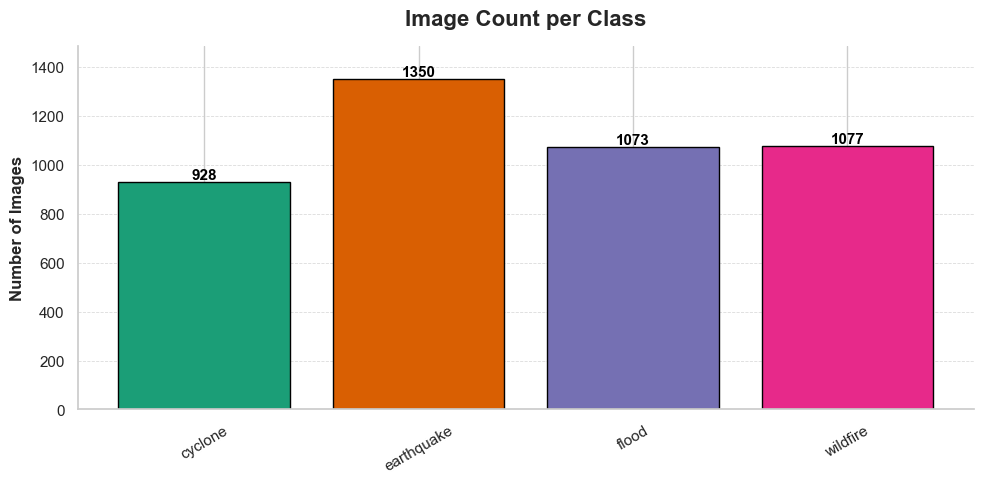

In [4]:
sns.set(style="whitegrid")

classes = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])

counts = []
for label in classes:
    folder_path = os.path.join(data_dir, label)
    count = len([f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))])
    counts.append(count)

plt.figure(figsize=(10, 5))
colors = sns.color_palette("Dark2", len(classes))
bars = plt.bar(classes, counts, color=colors, edgecolor='black')
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(count), ha='center', va='bottom', fontsize=11, weight='bold', color='black')
plt.title('Image Count per Class', fontsize=16, weight='bold', pad=15)
plt.ylabel('Number of Images', fontsize=12, weight='bold')
plt.xticks(rotation=30, fontsize=11)
plt.yticks(fontsize=11)
plt.ylim(0, max(counts) + max(counts)*0.1)
plt.grid(axis='y', linestyle='--', linewidth=0.6, alpha=0.7)
sns.despine()
plt.tight_layout()
plt.show()

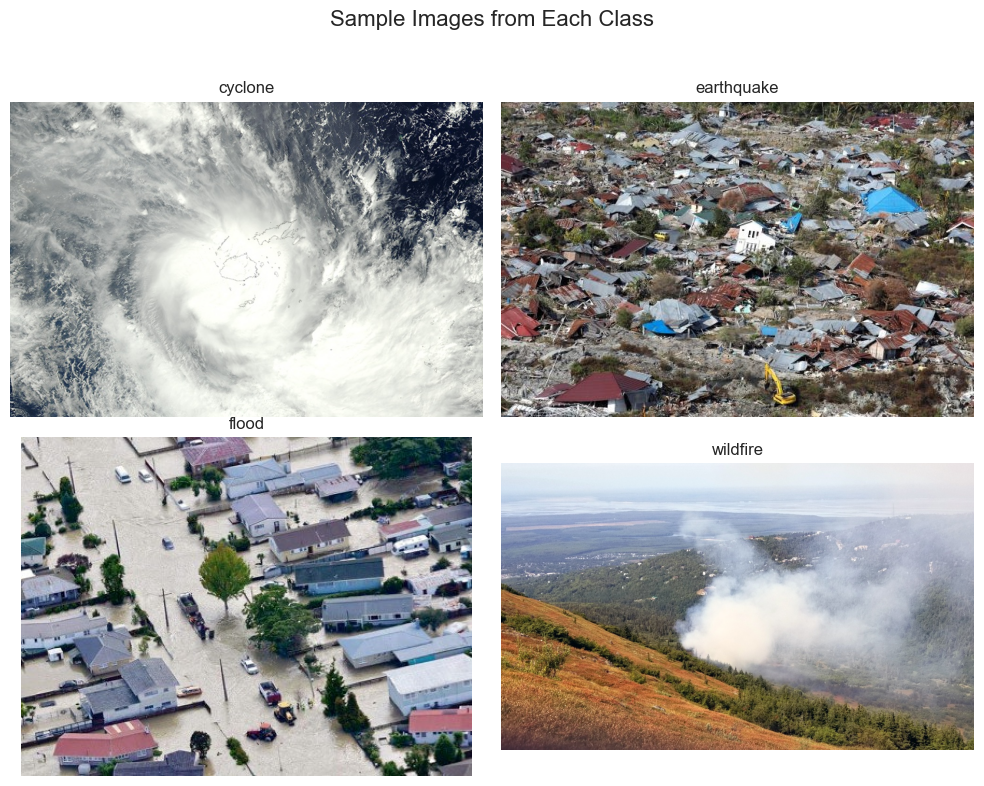

In [6]:
num_classes = len(classes)
cols = 2
rows = math.ceil(num_classes / cols)
plt.figure(figsize=(5 * cols, 4 * rows))
for idx, class_name in enumerate(classes):
    class_path = os.path.join(data_dir, class_name)
    image_files = [f for f in os.listdir(class_path)
                   if os.path.isfile(os.path.join(class_path, f)) and f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]
    if image_files:
        img_path = os.path.join(class_path, image_files[0])
        img = mpimg.imread(img_path)
        plt.subplot(rows, cols, idx + 1)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis('off')
plt.suptitle('Sample Images from Each Class', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [7]:
# --- Convert to NumPy Arrays ---
def dataset_to_numpy(dataset):
    x_data, y_data = [], []
    for images, labels in dataset:
        x_data.append(images.numpy())
        y_data.append(labels.numpy())
    return np.concatenate(x_data, axis=0), np.concatenate(y_data, axis=0)

x_train, y_train = dataset_to_numpy(train_data)
x_val, y_val = dataset_to_numpy(validation_data)

In [8]:
# --- One-hot Encode Labels ---
y_train = np.squeeze(y_train)
y_val = np.squeeze(y_val)

y_train = to_categorical(y_train, NUM_CLASSES)
y_val = to_categorical(y_val, NUM_CLASSES)

In [9]:
ML_Model = []
accuracy = []
precision = []
recall = []
f1score = []

def storeResults(model, a,b,c,d):
    ML_Model.append(model)
    accuracy.append(round(a, 3))
    precision.append(round(b, 3))
    recall.append(round(c, 3))
    f1score.append(round(d, 3))

In [10]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, auc
)
from sklearn.preprocessing import label_binarize


def evaluate_model(y_test, y_pred, y_proba, labels, history=None, model_name="Model"):
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="macro")
    rec = recall_score(y_test, y_pred, average="macro")
    f1 = f1_score(y_test, y_pred, average="macro")

    print(f"\nClassification Report - {model_name}")
    print(classification_report(y_test, y_pred, target_names=labels))

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap='Blues', xticks_rotation=90, ax=axes[0], colorbar=False)
    axes[0].set_title(f"Confusion Matrix - {model_name}")

    if len(np.unique(y_test)) > 2:
        y_test_bin = label_binarize(y_test, classes=range(len(labels)))
        for i in range(len(labels)):
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
            roc_auc_val = auc(fpr, tpr)
            axes[1].plot(fpr, tpr, lw=2, label=f"{labels[i]} (AUC={roc_auc_val:.2f})")
        axes[1].plot([0, 1], [0, 1], 'k--', lw=2)
        axes[1].set_title(f"ROC Curve - {model_name}")
        axes[1].legend(loc="lower right", fontsize=8)
    else:
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc_val = auc(fpr, tpr)
        axes[1].plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc_val:.2f}")
        axes[1].plot([0, 1], [0, 1], 'k--', lw=2)
        axes[1].legend(loc="lower right", fontsize=8)

    plt.tight_layout()
    plt.show()

    if history is not None:
        hist = history.history if hasattr(history, "history") else history

        fig, axes = plt.subplots(1, 2, figsize=(15, 6))
        axes[0].plot(hist["accuracy"], label="Train Accuracy")
        axes[0].plot(hist["val_accuracy"], label="Val Accuracy")
        axes[0].set_title(f"Training Accuracy - {model_name}")
        axes[0].set_xlabel("Epochs")
        axes[0].set_ylabel("Accuracy")
        axes[0].legend()

        axes[1].plot(hist["loss"], label="Train Loss")
        axes[1].plot(hist["val_loss"], label="Val Loss")
        axes[1].set_title(f"Training Loss - {model_name}")
        axes[1].set_xlabel("Epochs")
        axes[1].set_ylabel("Loss")
        axes[1].legend()

        plt.tight_layout()
        plt.show()

    return acc, prec, rec, f1

In [11]:
from tensorflow.keras.callbacks import EarlyStopping,  ReduceLROnPlateau

# Define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=5,          # Stop after 5 epochs with no improvement
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,         # Reduce LR by factor of 0.2
    patience=3,
    min_lr=1e-7,
    verbose=1
)


In [12]:
import os 

os.makedirs("Models", exist_ok=True)

In [13]:
labels = class_names

In [14]:
from tensorflow.keras.applications import Xception
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model


# Defining the pretrained base model
base = Xception(include_top=False, weights='imagenet', input_shape=(128, 128,3))
x = base.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)  # Add dropout before final layer
head = Dense(NUM_CLASSES, activation='softmax')(x)
xception_model = Model(inputs=base.input, outputs=head)

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
xception_model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

xception_model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 block1_conv1 (Conv2D)          (None, 63, 63, 32)   864         ['input_1[0][0]']                
                                                                                                  
 block1_conv1_bn (BatchNormaliz  (None, 63, 63, 32)  128         ['block1_conv1[0][0]']           
 ation)                                                                                           
                                                                                              

 n)                                                                                               
                                                                                                  
 block4_sepconv2 (SeparableConv  (None, 16, 16, 728)  536536     ['block4_sepconv2_act[0][0]']    
 2D)                                                                                              
                                                                                                  
 block4_sepconv2_bn (BatchNorma  (None, 16, 16, 728)  2912       ['block4_sepconv2[0][0]']        
 lization)                                                                                        
                                                                                                  
 conv2d_2 (Conv2D)              (None, 8, 8, 728)    186368      ['add_1[0][0]']                  
                                                                                                  
 block4_po

                                                                                                  
 block7_sepconv1_bn (BatchNorma  (None, 8, 8, 728)   2912        ['block7_sepconv1[0][0]']        
 lization)                                                                                        
                                                                                                  
 block7_sepconv2_act (Activatio  (None, 8, 8, 728)   0           ['block7_sepconv1_bn[0][0]']     
 n)                                                                                               
                                                                                                  
 block7_sepconv2 (SeparableConv  (None, 8, 8, 728)   536536      ['block7_sepconv2_act[0][0]']    
 2D)                                                                                              
                                                                                                  
 block7_se

                                                                  'add_6[0][0]']                  
                                                                                                  
 block10_sepconv1_act (Activati  (None, 8, 8, 728)   0           ['add_7[0][0]']                  
 on)                                                                                              
                                                                                                  
 block10_sepconv1 (SeparableCon  (None, 8, 8, 728)   536536      ['block10_sepconv1_act[0][0]']   
 v2D)                                                                                             
                                                                                                  
 block10_sepconv1_bn (BatchNorm  (None, 8, 8, 728)   2912        ['block10_sepconv1[0][0]']       
 alization)                                                                                       
          

 block12_sepconv3 (SeparableCon  (None, 8, 8, 728)   536536      ['block12_sepconv3_act[0][0]']   
 v2D)                                                                                             
                                                                                                  
 block12_sepconv3_bn (BatchNorm  (None, 8, 8, 728)   2912        ['block12_sepconv3[0][0]']       
 alization)                                                                                       
                                                                                                  
 add_10 (Add)                   (None, 8, 8, 728)    0           ['block12_sepconv3_bn[0][0]',    
                                                                  'add_9[0][0]']                  
                                                                                                  
 block13_sepconv1_act (Activati  (None, 8, 8, 728)   0           ['add_10[0][0]']                 
 on)      

In [15]:
history_xception = xception_model.fit(
    x_train,
    y_train,
    batch_size=4,
    epochs=50,
    validation_data=(x_val, y_val),
    shuffle=True,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/50
886/886 [==============================] - 36s 26ms/step - loss: 0.5718 - accuracy: 0.7948 - val_loss: 1.0955 - val_accuracy: 0.8915 - lr: 1.0000e-04
Epoch 2/50
886/886 [==============================] - 22s 25ms/step - loss: 0.3168 - accuracy: 0.8953 - val_loss: 1.7197 - val_accuracy: 0.8972 - lr: 1.0000e-04
Epoch 3/50
886/886 [==============================] - 22s 25ms/step - loss: 0.2344 - accuracy: 0.9280 - val_loss: 0.2498 - val_accuracy: 0.9379 - lr: 1.0000e-04
Epoch 4/50
886/886 [==============================] - 22s 24ms/step - loss: 0.1358 - accuracy: 0.9596 - val_loss: 0.2947 - val_accuracy: 0.9401 - lr: 1.0000e-04
Epoch 5/50
886/886 [==============================] - 21s 24ms/step - loss: 0.1224 - accuracy: 0.9667 - val_loss: 0.5352 - val_accuracy: 0.9333 - lr: 1.0000e-04
Epoch 6/50
886/886 [==============================] - 22s 24ms/step - loss: 0.1067 - accuracy: 0.9718 - val_loss: 0.0761 - val_accuracy: 0.9853 - lr: 1.0000e-04
Epoch 7/50
886/886 [==============

In [16]:
xception_model.save("Models/xception.h5")

222/222 [==============================] - 2s 6ms/step

Classification Report - Xception
              precision    recall  f1-score   support

     cyclone       1.00      0.99      0.99       186
  earthquake       1.00      0.99      0.99       262
       flood       0.97      1.00      0.98       231
    wildfire       0.98      0.97      0.97       206

    accuracy                           0.99       885
   macro avg       0.99      0.98      0.99       885
weighted avg       0.99      0.99      0.99       885



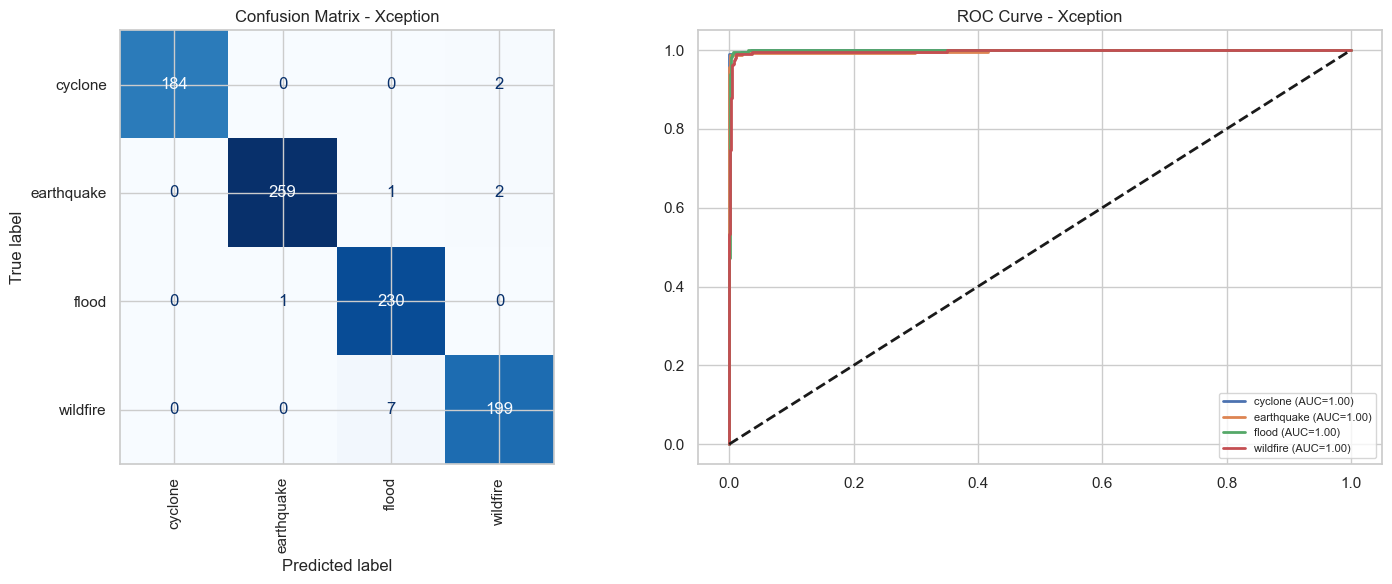

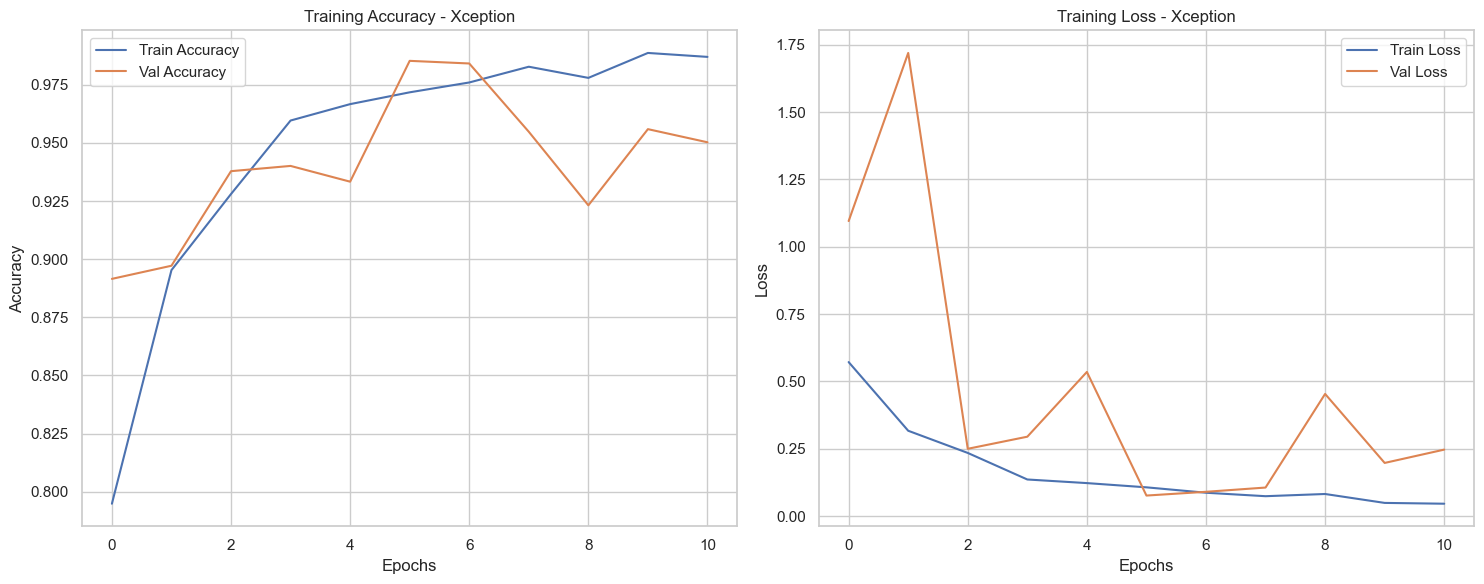

In [17]:
y_val_int = np.argmax(y_val, axis=1)

y_proba_xception = xception_model.predict(x_val, batch_size=4)
y_pred_xception = np.argmax(y_proba_xception, axis=1)

acc_xception, prec_xception, rec_xception, f1_xception = evaluate_model(
    y_val_int,
    y_pred_xception,
    y_proba_xception,
    labels,
    history=history_xception,
    model_name="Xception"
)



In [18]:
storeResults("Xception", acc_xception, prec_xception, rec_xception, f1_xception)

# ResNet50

In [19]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

base_resnet = ResNet50(include_top=False, weights='imagenet', input_shape=(128, 128, 3))

x = base_resnet.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)  
head = Dense(NUM_CLASSES, activation='softmax')(x)

resnet_model = Model(inputs=base_resnet.input, outputs=head)

optimizer = Adam(learning_rate=1e-4)
resnet_model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

resnet_model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 134, 134, 3)  0           ['input_2[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 64, 64, 64)   9472        ['conv1_pad[0][0]']              
                                                                                                  
 conv1_bn (BatchNormalization)  (None, 64, 64, 64)   256         ['conv1_conv[0][0]']       

 conv2_block3_2_conv (Conv2D)   (None, 32, 32, 64)   36928       ['conv2_block3_1_relu[0][0]']    
                                                                                                  
 conv2_block3_2_bn (BatchNormal  (None, 32, 32, 64)  256         ['conv2_block3_2_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv2_block3_2_relu (Activatio  (None, 32, 32, 64)  0           ['conv2_block3_2_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv2_block3_3_conv (Conv2D)   (None, 32, 32, 256)  16640       ['conv2_block3_2_relu[0][0]']    
                                                                                                  
 conv2_blo

 conv3_block3_2_conv (Conv2D)   (None, 16, 16, 128)  147584      ['conv3_block3_1_relu[0][0]']    
                                                                                                  
 conv3_block3_2_bn (BatchNormal  (None, 16, 16, 128)  512        ['conv3_block3_2_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv3_block3_2_relu (Activatio  (None, 16, 16, 128)  0          ['conv3_block3_2_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv3_block3_3_conv (Conv2D)   (None, 16, 16, 512)  66048       ['conv3_block3_2_relu[0][0]']    
                                                                                                  
 conv3_blo

 conv4_block2_2_conv (Conv2D)   (None, 8, 8, 256)    590080      ['conv4_block2_1_relu[0][0]']    
                                                                                                  
 conv4_block2_2_bn (BatchNormal  (None, 8, 8, 256)   1024        ['conv4_block2_2_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv4_block2_2_relu (Activatio  (None, 8, 8, 256)   0           ['conv4_block2_2_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv4_block2_3_conv (Conv2D)   (None, 8, 8, 1024)   263168      ['conv4_block2_2_relu[0][0]']    
                                                                                                  
 conv4_blo

 conv4_block5_2_relu (Activatio  (None, 8, 8, 256)   0           ['conv4_block5_2_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv4_block5_3_conv (Conv2D)   (None, 8, 8, 1024)   263168      ['conv4_block5_2_relu[0][0]']    
                                                                                                  
 conv4_block5_3_bn (BatchNormal  (None, 8, 8, 1024)  4096        ['conv4_block5_3_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv4_block5_add (Add)         (None, 8, 8, 1024)   0           ['conv4_block4_out[0][0]',       
                                                                  'conv4_block5_3_bn[0][0]']      
          

 conv5_block2_2_relu (Activatio  (None, 4, 4, 512)   0           ['conv5_block2_2_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv5_block2_3_conv (Conv2D)   (None, 4, 4, 2048)   1050624     ['conv5_block2_2_relu[0][0]']    
                                                                                                  
 conv5_block2_3_bn (BatchNormal  (None, 4, 4, 2048)  8192        ['conv5_block2_3_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv5_block2_add (Add)         (None, 4, 4, 2048)   0           ['conv5_block1_out[0][0]',       
                                                                  'conv5_block2_3_bn[0][0]']      
          

In [20]:
history_resnet = resnet_model.fit(
    x_train,
    y_train,
    batch_size=4,
    epochs=50,
    validation_data=(x_val, y_val),
    shuffle=True,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/50
886/886 [==============================] - 36s 35ms/step - loss: 0.5611 - accuracy: 0.7931 - val_loss: 0.2263 - val_accuracy: 0.9266 - lr: 1.0000e-04
Epoch 2/50
886/886 [==============================] - 29s 33ms/step - loss: 0.2989 - accuracy: 0.8905 - val_loss: 0.1327 - val_accuracy: 0.9503 - lr: 1.0000e-04
Epoch 3/50
886/886 [==============================] - 29s 33ms/step - loss: 0.2054 - accuracy: 0.9292 - val_loss: 0.0574 - val_accuracy: 0.9797 - lr: 1.0000e-04
Epoch 4/50
886/886 [==============================] - 29s 33ms/step - loss: 0.1441 - accuracy: 0.9509 - val_loss: 0.0717 - val_accuracy: 0.9763 - lr: 1.0000e-04
Epoch 5/50
886/886 [==============================] - 30s 33ms/step - loss: 0.1130 - accuracy: 0.9616 - val_loss: 0.0841 - val_accuracy: 0.9751 - lr: 1.0000e-04
Epoch 6/50
886/886 [==============================] - ETA: 0s - loss: 0.0934 - accuracy: 0.9675
Epoch 6: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.
886/886 [=============

In [21]:
resnet_model.save("Models/resnet.h5")

222/222 [==============================] - 3s 9ms/step

Classification Report - ResNet50
              precision    recall  f1-score   support

     cyclone       0.99      0.99      0.99       186
  earthquake       0.99      0.99      0.99       262
       flood       1.00      0.99      0.99       231
    wildfire       0.98      1.00      0.99       206

    accuracy                           0.99       885
   macro avg       0.99      0.99      0.99       885
weighted avg       0.99      0.99      0.99       885



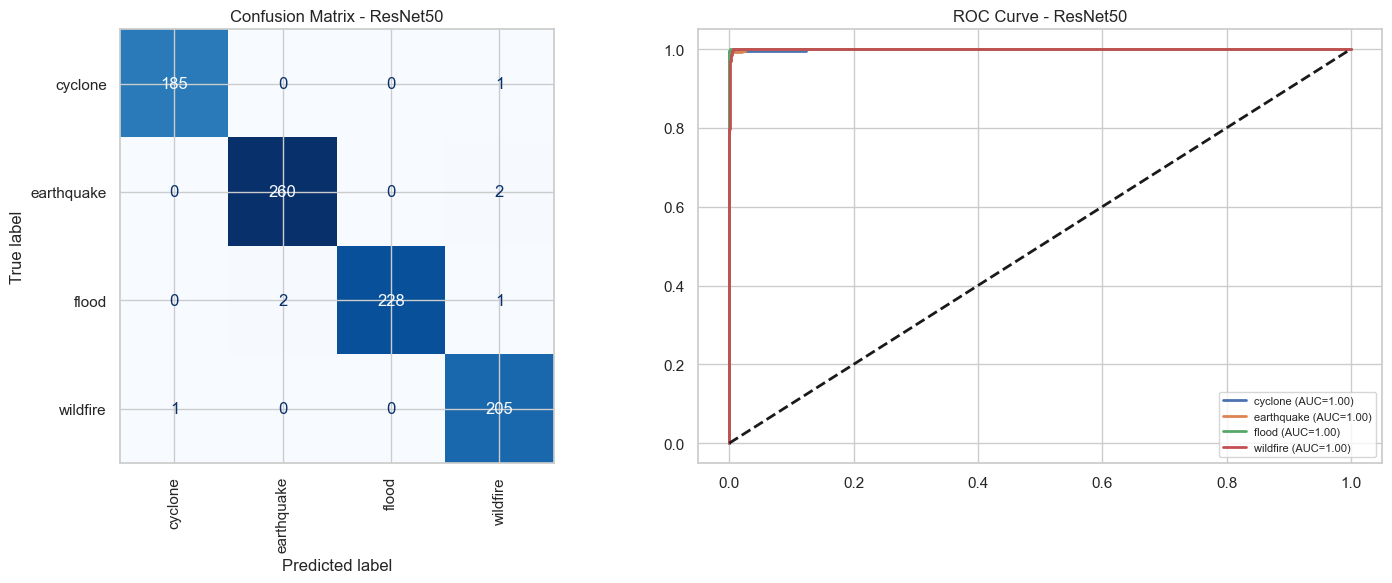

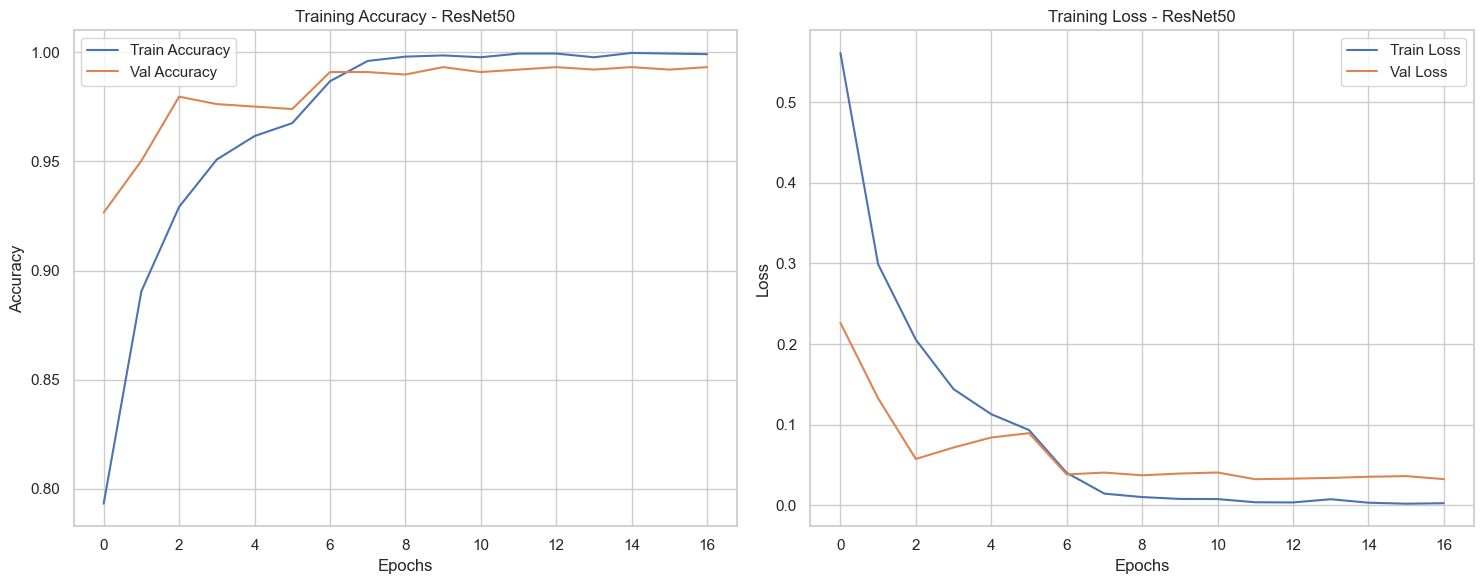

In [22]:
y_val_int = np.argmax(y_val, axis=1)

y_proba_resnet = resnet_model.predict(x_val, batch_size=4)
y_pred_resnet = np.argmax(y_proba_resnet, axis=1)

acc_resnet, prec_resnet, rec_resnet, f1_resnet = evaluate_model(
    y_val_int,
    y_pred_resnet,
    y_proba_resnet,
    labels,
    history=history_resnet,
    model_name="ResNet50"
)

In [23]:
storeResults("ResNet50", acc_resnet, prec_resnet, rec_resnet, f1_resnet)

# Hybrid Ensemble

In [24]:
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Average, Input
from tensorflow.keras.models import Model

In [25]:
def ensemble():
    model_1 = load_model("Models/xception.h5", compile=False)
    model_2 = load_model("Models/resnet.h5", compile=False) 
    
    models = [model_1, model_2]

    models_input = Input(shape=(128, 128, 3))

    models_output = [model(models_input) for model in models]

    ensemble_output = Average()(models_output)

    simple_average = Model(inputs=models_input, outputs=ensemble_output, name="Ensemble")

    return simple_average


In [26]:
hybrid = ensemble()

optimizer = Adam(learning_rate=1e-4)
hybrid.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

hybrid.summary()

Model: "Ensemble"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_3 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 model (Functional)             (None, 4)            20869676    ['input_3[0][0]']                
                                                                                                  
 model_1 (Functional)           (None, 4)            23595908    ['input_3[0][0]']                
                                                                                                  
 average (Average)              (None, 4)            0           ['model[0][0]',           

In [27]:
history_hybrid = hybrid.fit(
    x_train,
    y_train,
    batch_size=4,
    epochs=50,
    validation_data=(x_val, y_val),
    shuffle=True,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/50
886/886 [==============================] - 61s 59ms/step - loss: 0.0584 - accuracy: 0.9879 - val_loss: 0.0792 - val_accuracy: 0.9797 - lr: 1.0000e-04
Epoch 2/50
886/886 [==============================] - 50s 56ms/step - loss: 0.0541 - accuracy: 0.9870 - val_loss: 0.1413 - val_accuracy: 0.9435 - lr: 1.0000e-04
Epoch 3/50
886/886 [==============================] - 50s 56ms/step - loss: 0.0421 - accuracy: 0.9929 - val_loss: 0.1048 - val_accuracy: 0.9593 - lr: 1.0000e-04
Epoch 4/50
886/886 [==============================] - 50s 56ms/step - loss: 0.0447 - accuracy: 0.9918 - val_loss: 0.0579 - val_accuracy: 0.9910 - lr: 1.0000e-04
Epoch 5/50
886/886 [==============================] - 50s 56ms/step - loss: 0.0612 - accuracy: 0.9836 - val_loss: 0.1236 - val_accuracy: 0.9627 - lr: 1.0000e-04
Epoch 6/50
886/886 [==============================] - 50s 56ms/step - loss: 0.0688 - accuracy: 0.9853 - val_loss: 0.0984 - val_accuracy: 0.9740 - lr: 1.0000e-04
Epoch 7/50
886/886 [==============

In [28]:
hybrid.save("Models/ensemble_hybrid.h5")

222/222 [==============================] - 4s 12ms/step

Classification Report - Hybrid-Ensemble
              precision    recall  f1-score   support

     cyclone       1.00      0.98      0.99       186
  earthquake       0.99      0.99      0.99       262
       flood       1.00      0.99      0.99       231
    wildfire       0.98      1.00      0.99       206

    accuracy                           0.99       885
   macro avg       0.99      0.99      0.99       885
weighted avg       0.99      0.99      0.99       885



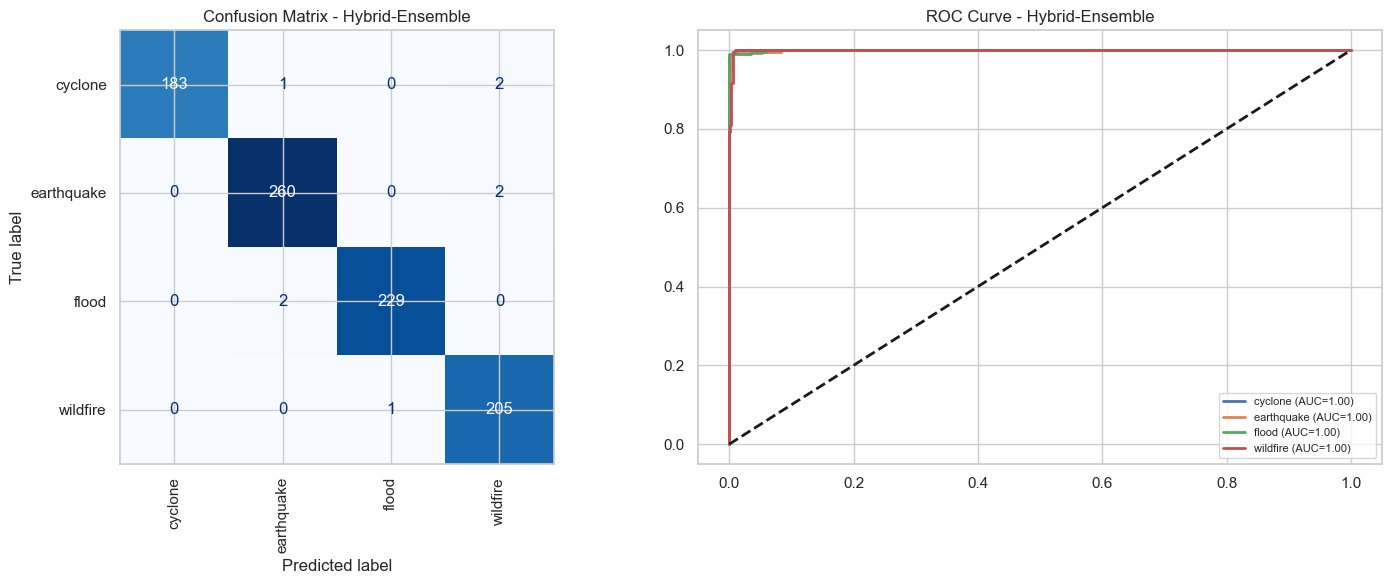

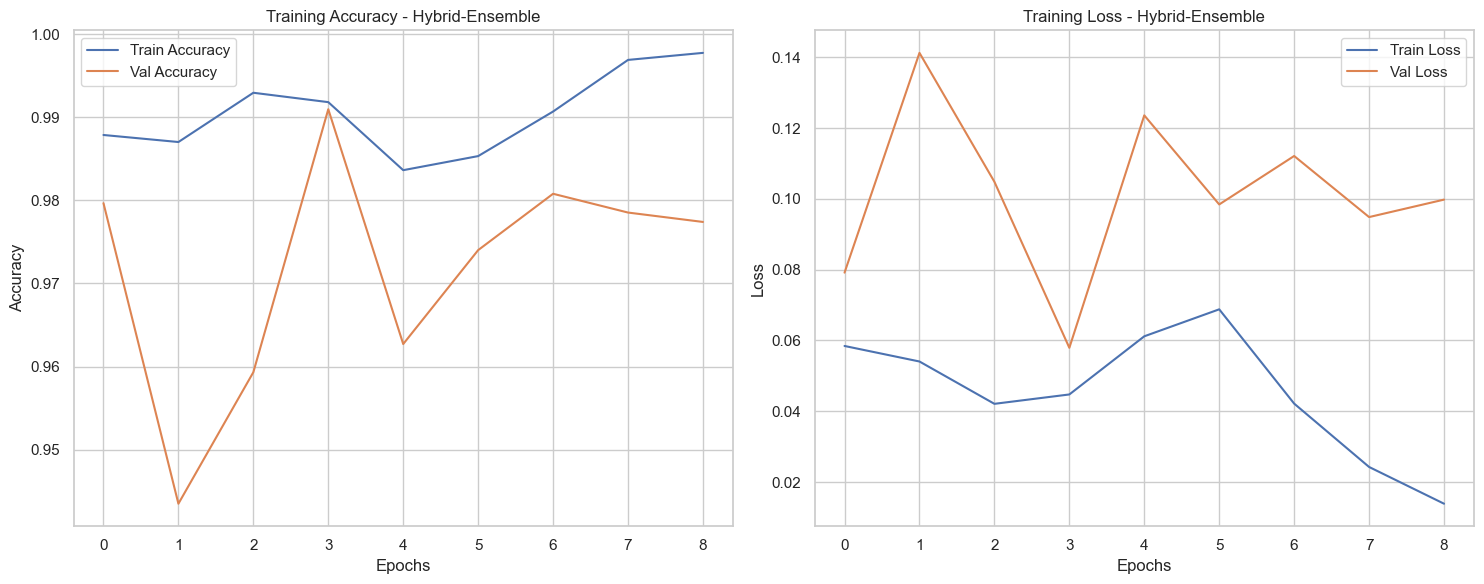

In [29]:
y_val_int = np.argmax(y_val, axis=1)

y_proba_hybrid = hybrid.predict(x_val, batch_size=4)
y_pred_hybrid = np.argmax(y_proba_hybrid, axis=1)

acc_hybrid, prec_hybrid, rec_hybrid, f1_hybrid = evaluate_model(
    y_val_int,
    y_pred_hybrid,
    y_proba_hybrid,
    labels,
    history=history_hybrid,
    model_name="Hybrid-Ensemble"
)

In [30]:
storeResults("Hybrid-Ensemble", acc_hybrid, prec_hybrid, rec_hybrid, f1_hybrid)

# Proposed Comparsion Table

Since we built the proposed model in separate notebooks, we are writing the metric results manually here.

In [99]:
import pandas as pd

data = {
    "ML Model": ["ERI-2025+XGBoost+SVM", "DRI-2025+XGBoost+SVM", "DE-2025+XGBoost+SVM"],
    "Accuracy": [0.931, 0.931, 0.902],
    "Precision": [0.938, 0.936, 0.915],
    "Recall": [0.937, 0.936, 0.911],
    "F1_score": [0.935, 0.934, 0.908]
}

result1 = pd.DataFrame(data)


In [100]:
result1

,ML Model,Accuracy,Precision,Recall,F1_score
0,ERI-2025+XGBoost+SVM,0.931,0.938,0.937,0.935
1,DRI-2025+XGBoost+SVM,0.931,0.936,0.936,0.934
2,DE-2025+XGBoost+SVM,0.902,0.915,0.911,0.908


# Extension comparison Table

In [101]:
import pandas as pd
result2 = pd.DataFrame({ 'ML Model' : ML_Model,
                        'Accuracy' : accuracy,
                       'Precision': precision,
                       'Recall'   : recall, 
                       'F1_score' : f1score                   
                      })

In [102]:
result2

,ML Model,Accuracy,Precision,Recall,F1_score
0,Xception,0.985,0.986,0.985,0.985
1,ResNet50,0.992,0.992,0.992,0.992
2,Hybrid-Ensemble,0.991,0.991,0.991,0.991


# Final Comparison Table

In [103]:
result = pd.concat([result1, result2], axis=0)

In [104]:
result

,ML Model,Accuracy,Precision,Recall,F1_score
0,ERI-2025+XGBoost+SVM,0.931,0.938,0.937,0.935
1,DRI-2025+XGBoost+SVM,0.931,0.936,0.936,0.934
2,DE-2025+XGBoost+SVM,0.902,0.915,0.911,0.908
0,Xception,0.985,0.986,0.985,0.985
1,ResNet50,0.992,0.992,0.992,0.992
2,Hybrid-Ensemble,0.991,0.991,0.991,0.991


# Graph

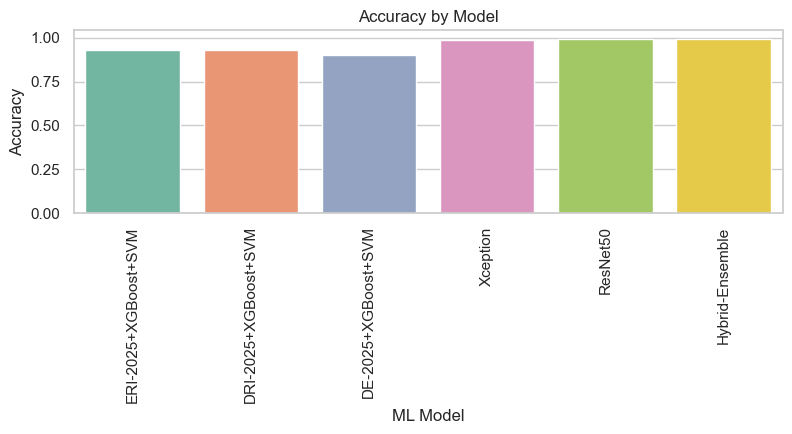

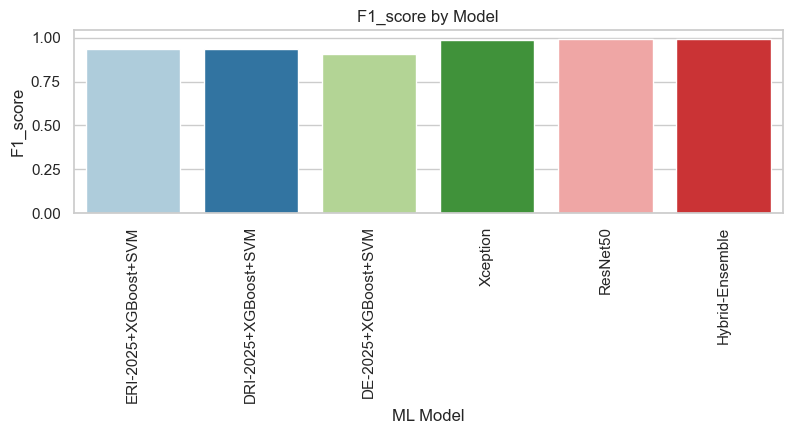

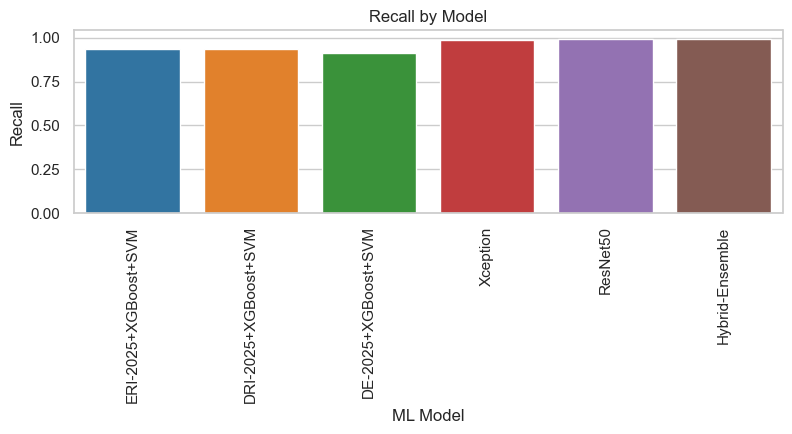

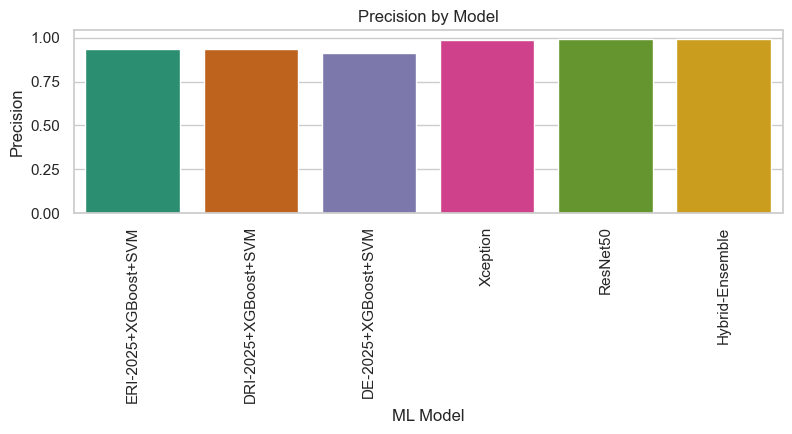

In [105]:
import matplotlib.pyplot as plt
import seaborn as sns

palettes = ['Set2', 'Paired', 'tab10', 'Dark2']

for metric, pal in zip(['Accuracy','F1_score','Recall','Precision'], palettes):
    plt.figure(figsize=(8, 4.5))
    sns.barplot(data=result, x='ML Model', y=metric, palette=sns.color_palette(pal))
    plt.title(f'{metric} by Model')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()


# Prediction

In [106]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import cv2
from tensorflow.keras.applications.efficientnet import preprocess_input

In [107]:
model = load_model('Models/ensemble_hybrid.h5',  compile=False)

model.summary()

Model: "Ensemble"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_3 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 model (Functional)             (None, 4)            20869676    ['input_3[0][0]']                
                                                                                                  
 model_1 (Functional)           (None, 4)            23595908    ['input_3[0][0]']                
                                                                                                  
 average (Average)              (None, 4)            0           ['model[0][0]',           

In [108]:
# Load and preprocess the image
file_path = "dataset_combined/cyclone/test_792.jpg"

In [109]:
img = load_img(file_path, target_size=(128, 128))
img_array = img_to_array(img)
img_preprocessed = preprocess_input(img_array)
input_tensor = np.expand_dims(img_preprocessed, axis=0)

# Prediction
pred = model.predict(input_tensor)
predicted_class = np.argmax(pred)
print("Predicted class index:", predicted_class)

1/1 [==============================] - 1s 1s/step
Predicted class index: 0


In [110]:
file_path = "dataset_combined/flood/test_929.jpg"

img = load_img(file_path, target_size=(128, 128))
img_array = img_to_array(img)
img_preprocessed = preprocess_input(img_array)
input_tensor = np.expand_dims(img_preprocessed, axis=0)

# Prediction
pred = model.predict(input_tensor)
predicted_class = np.argmax(pred)
print("Predicted class index:", predicted_class)

1/1 [==============================] - 0s 31ms/step
Predicted class index: 2


# Grad Cam

Last conv layer: block14_sepconv2_act


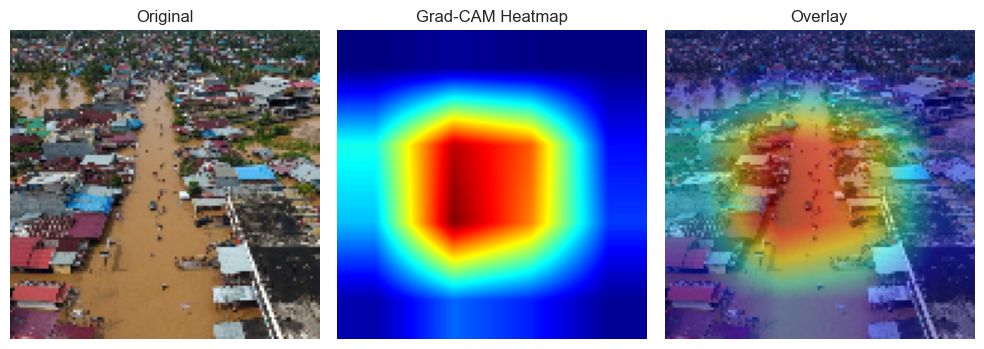

In [111]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import cv2
from tensorflow.keras.models import Model

submodel = model.get_layer('model')

last_conv = None
for layer in reversed(submodel.layers):
    if len(layer.output_shape) == 4:
        last_conv = layer.name
        break
print("Last conv layer:", last_conv)

# Grad-CAM Function
def make_gradcam(model, img_tensor, class_idx):
    grad_model = Model([model.inputs], [model.get_layer(last_conv).output, model.output])
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_tensor)
        loss = preds[:, class_idx]
    grads = tape.gradient(loss, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_out = conv_out[0]
    heatmap = tf.reduce_sum(tf.multiply(pooled_grads, conv_out), axis=-1)
    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap)
    return heatmap

# --- Generate heatmap ---
heatmap = make_gradcam(submodel, input_tensor, predicted_class)

# --- Overlay Grad-CAM ---
img = cv2.imread(file_path)
img = cv2.resize(img, (128, 128))
heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
heatmap = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
superimposed = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)

# --- Show results ---
plt.figure(figsize=(10,4))
plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1,3,2)
plt.title("Grad-CAM Heatmap")
plt.imshow(heatmap[..., ::-1])
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Overlay")
plt.imshow(cv2.cvtColor(superimposed, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.tight_layout()
plt.show()


# XAI-LIME

In [112]:
import cv2
from lime import lime_image
from skimage.segmentation import mark_boundaries


class_names = ['cyclone', 'earthquake', 'flood', 'wildfire']

file_path = "dataset_combined/flood/test_929.jpg"

img = load_img(file_path, target_size=(128, 128))
img_array = img_to_array(img)
img_preprocessed = preprocess_input(img_array)
input_tensor = np.expand_dims(img_preprocessed, axis=0)

# Prediction
pred = model.predict(input_tensor)
predicted_class = np.argmax(pred)

def predict_fn(images):
    images = preprocess_input(np.array(images).astype(np.float32))
    return model.predict(images)

orig_img = img_array.astype('double')   
h, w = orig_img.shape[:2]

explainer = lime_image.LimeImageExplainer()

explanation = explainer.explain_instance(
    orig_img,
    predict_fn,
    top_labels=5,
    hide_color=0,
    num_samples=1000
)

lime_img, mask = explanation.get_image_and_mask(
    label=predicted_class,
    positive_only=True,
    hide_rest=False,
    num_features=5,
    min_weight=0.0
)

orig_uint8 = orig_img.astype('uint8')

colored_mask = mark_boundaries(orig_uint8, mask)

orig_bgr = cv2.cvtColor(orig_uint8, cv2.COLOR_RGB2BGR)
mask_bgr = cv2.cvtColor((colored_mask * 255).astype('uint8'), cv2.COLOR_RGB2BGR)

overlay_bgr = cv2.addWeighted(orig_bgr, 0.6, mask_bgr, 0.4, 0)

overlay_rgb = cv2.cvtColor(overlay_bgr, cv2.COLOR_BGR2RGB)





1/1 [==============================] - 0s 31ms/step


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 [==============================] - 0s 32ms/step


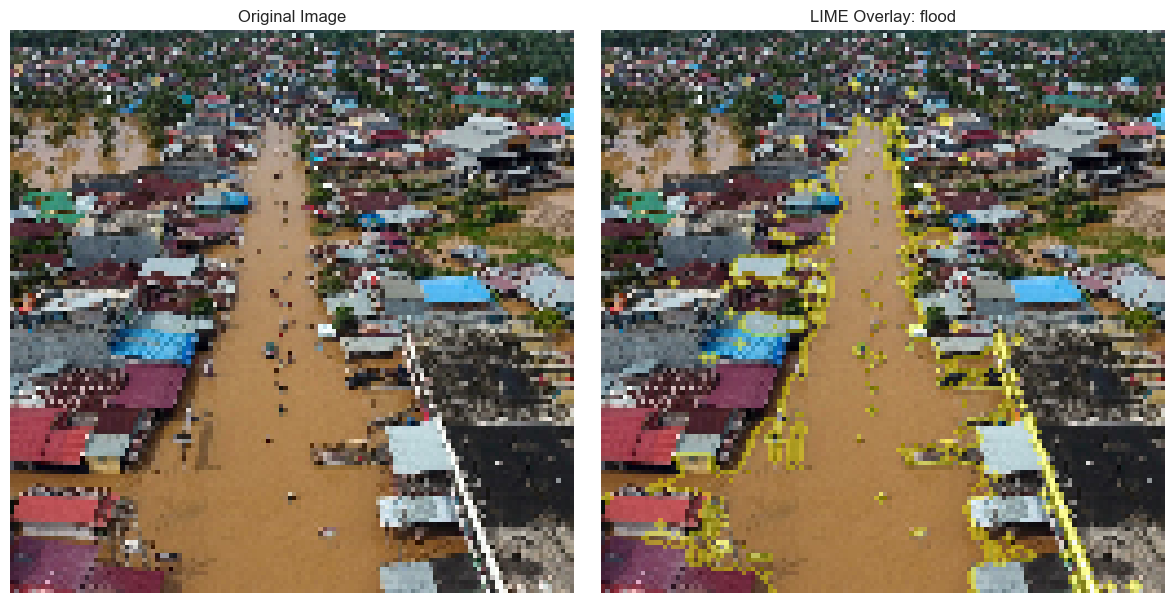

In [113]:
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(orig_uint8)
plt.axis('off')

plt.subplot(1,2,2)
plt.title(f"LIME Overlay: {class_names[predicted_class]}")
plt.imshow(overlay_rgb)
plt.axis('off')

plt.tight_layout()
plt.show()

In [114]:
file_path = "dataset_combined/cyclone/test_792.jpg"  

img = load_img(file_path, target_size=(128, 128))
img_array = img_to_array(img)
img_preprocessed = preprocess_input(img_array)
input_tensor = np.expand_dims(img_preprocessed, axis=0)

pred = model.predict(input_tensor)
predicted_class = np.argmax(pred)

print("Predicted Class:", class_names[predicted_class])

orig_img = img_array.astype('double')
orig_uint8 = img_array.astype('uint8')

explanation = explainer.explain_instance(
    orig_img,
    predict_fn,
    top_labels=5,
    hide_color=0,
    num_samples=1000
)

lime_img, mask = explanation.get_image_and_mask(
    label=predicted_class,
    positive_only=True,
    hide_rest=False,
    num_features=5,
    min_weight=0.0
)

colored_mask = mark_boundaries(orig_uint8, mask)

orig_bgr = cv2.cvtColor(orig_uint8, cv2.COLOR_RGB2BGR)
mask_bgr = cv2.cvtColor((colored_mask * 255).astype('uint8'), cv2.COLOR_RGB2BGR)

overlay_bgr = cv2.addWeighted(orig_bgr, 0.6, mask_bgr, 0.4, 0)
overlay_rgb = cv2.cvtColor(overlay_bgr, cv2.COLOR_BGR2RGB)

1/1 [==============================] - 0s 32ms/step
Predicted Class: cyclone


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 [==============================] - 0s 31ms/step


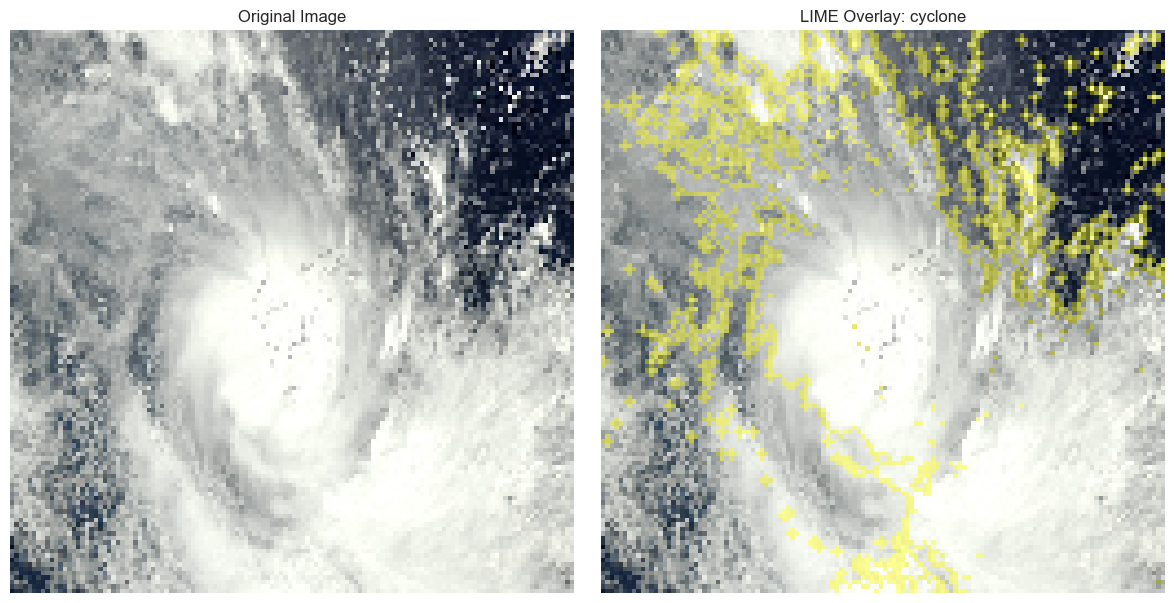

In [115]:
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(orig_uint8)
plt.axis('off')

plt.subplot(1,2,2)
plt.title(f"LIME Overlay: {class_names[predicted_class]}")
plt.imshow(overlay_rgb)
plt.axis('off')

plt.tight_layout()
plt.show()

In [116]:
import shap
import numpy as np
import matplotlib.pyplot as plt


In [117]:
# load 20 background images for SHAP
background = []

for i in range(20):
    path = f"dataset_combined/cyclone/test_{792+i}.jpg"
    bg_img = load_img(path, target_size=(128,128))
    bg_arr = img_to_array(bg_img)
    background.append(bg_arr)

background = np.array(background)
background = preprocess_input(background.astype(np.float32))


In [118]:
explainer = shap.GradientExplainer(model, background)


In [119]:
# SHAP expects preprocessed input
shap_values = explainer.shap_values(input_tensor)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-8.064919256867142e-07..1.0796484275488183e-06].


<Figure size 800x800 with 0 Axes>

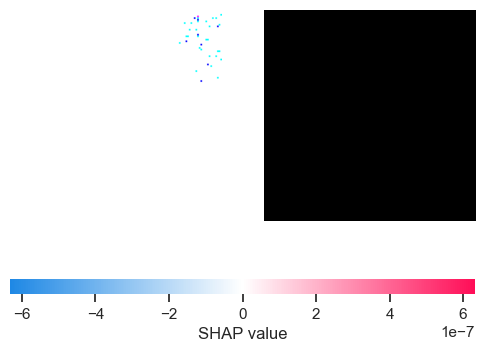

In [120]:
plt.figure(figsize=(8,8))
shap.image_plot(shap_values, np.array([img_array]))


In [121]:
# Convert SHAP values to grayscale mask
shap_mask = np.mean(np.abs(shap_values[0][0]), axis=-1)

# Normalize
shap_mask = (shap_mask - shap_mask.min()) / (shap_mask.max() - shap_mask.min())
shap_mask = cv2.resize(shap_mask, (128, 128))

# Convert to heatmap
heatmap = cv2.applyColorMap(np.uint8(255 * shap_mask), cv2.COLORMAP_JET)

# Overlay
orig_bgr = cv2.cvtColor(orig_uint8, cv2.COLOR_RGB2BGR)
overlay_shap_bgr = cv2.addWeighted(orig_bgr, 0.6, heatmap, 0.4, 0)
overlay_shap_rgb = cv2.cvtColor(overlay_shap_bgr, cv2.COLOR_BGR2RGB)


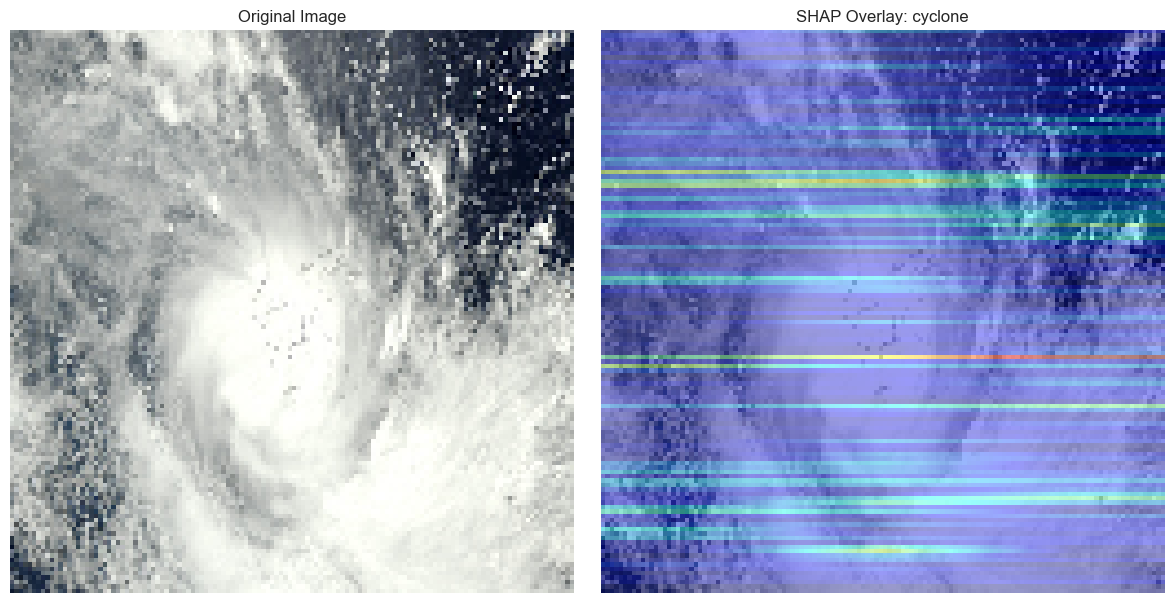

In [122]:
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(orig_uint8)
plt.axis('off')

plt.subplot(1,2,2)
plt.title(f"SHAP Overlay: {class_names[predicted_class]}")
plt.imshow(overlay_shap_rgb)
plt.axis('off')

plt.tight_layout()
plt.show()


In [123]:
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt

def to_display(img_bgr):
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

def make_overlay_from_mask(mask, orig_uint8, alpha=0.4):
    heatmap = cv2.applyColorMap(np.uint8(255 * mask), cv2.COLORMAP_JET)
    orig_bgr_local = cv2.cvtColor(orig_uint8, cv2.COLOR_RGB2BGR)
    overlay_bgr_local = cv2.addWeighted(orig_bgr_local, 1.0 - alpha, heatmap, alpha, 0)
    return cv2.cvtColor(overlay_bgr_local, cv2.COLOR_BGR2RGB)


try:
    submodel = model.get_layer("model")       
except:
    raise RuntimeError("Model has no layer named 'model' containing conv layers.")

last_conv = None
for layer in reversed(submodel.layers):
    try:
        if len(layer.output_shape) == 4:
            last_conv = layer.name
            break
    except:
        pass

if last_conv is None:
    raise RuntimeError("No convolution layer found inside submodel.")

print("Using last conv layer:", last_conv)

H, W = orig_uint8.shape[:2]

# SmoothGrad
def smoothgrad(model, input_tensor, class_idx, stdev_spread=0.15, nsamples=50):
    input_arr = input_tensor.astype(np.float32)
    stdev = stdev_spread * (np.max(input_arr) - np.min(input_arr))
    grads_accum = np.zeros_like(input_arr, dtype=np.float32)

    for _ in range(nsamples):
        noise = np.random.normal(0, stdev, size=input_arr.shape).astype(np.float32)
        noisy_tf = tf.convert_to_tensor(input_arr + noise)
        with tf.GradientTape() as tape:
            tape.watch(noisy_tf)
            preds = model(noisy_tf)
            loss = preds[:, class_idx]
        grads = tape.gradient(loss, noisy_tf).numpy()
        grads_accum += grads

    avg_grads = grads_accum / nsamples
    saliency = np.mean(np.abs(avg_grads[0]), axis=-1)
    saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-10)
    return saliency

# Integrated Gradients
def integrated_gradients(model, input_tensor, class_idx, baseline=None, steps=50):

    if baseline is None:
        baseline = np.zeros_like(input_tensor, dtype=np.float32)

    alphas = np.linspace(0, 1, steps).astype(np.float32)
    interpolated = baseline + alphas[:, None, None, None] * (input_tensor - baseline)

    interpolated_tf = tf.convert_to_tensor(interpolated)
    with tf.GradientTape() as tape:
        tape.watch(interpolated_tf)
        preds = model(interpolated_tf)
        loss = preds[:, class_idx]

    grads = tape.gradient(loss, interpolated_tf).numpy()
    avg_grads = np.mean(grads, axis=0)

    integrated = (input_tensor[0] - baseline[0]) * avg_grads
    ig_mask = np.mean(np.abs(integrated), axis=-1)

    ig_mask = (ig_mask - ig_mask.min()) / (ig_mask.max() - ig_mask.min() + 1e-10)
    return ig_mask


# Score-CAM 
def scorecam(full_model, input_tensor, class_idx, conv_model, last_conv_layer, max_maps=64):

    conv_layer = conv_model.get_layer(last_conv_layer)
    extractor = tf.keras.Model(inputs=conv_model.inputs, outputs=conv_layer.output)

    conv_out = extractor(input_tensor)[0].numpy()  # (h, w, c)
    hmap, wmap, n_maps = conv_out.shape

    # Select strongest maps
    energy = np.linalg.norm(conv_out.reshape(-1, n_maps), axis=0)
    if max_maps < n_maps:
        top_idx = np.argsort(energy)[-max_maps:]
    else:
        top_idx = np.arange(n_maps)

    weights = []
    upsampled_maps = []

    for i in top_idx:
        fmap = conv_out[..., i]
        fmap_resized = cv2.resize(fmap, (W, H))

        fmap_norm = (fmap_resized - fmap_resized.min()) / (fmap_resized.max() - fmap_resized.min() + 1e-10)
        upsampled_maps.append(fmap_norm)

        masked = orig_uint8.astype(np.float32) * fmap_norm[..., None]
        masked_pre = preprocess_input(masked.astype(np.float32))[None, ...]

        prob = full_model.predict(masked_pre)[0][class_idx]
        weights.append(prob)

    weights = np.array(weights)
    weights /= weights.max() + 1e-10

    heat = np.zeros((H, W), np.float32)
    for w, fmap in zip(weights, upsampled_maps):
        heat += w * fmap

    heat = np.maximum(heat, 0)
    heat = (heat - heat.min()) / (heat.max() - heat.min() + 1e-10)
    return heat


print("\nComputing SmoothGrad...")
sg_mask = smoothgrad(model, input_tensor, predicted_class)

print("Computing Integrated Gradients...")
baseline = np.zeros_like(input_tensor, dtype=np.float32)
ig_mask = integrated_gradients(model, input_tensor, predicted_class, baseline=baseline)

print("Computing Score-CAM...")
sc_mask = scorecam(model, input_tensor, predicted_class, submodel, last_conv, max_maps=64)

overlay_sg = make_overlay_from_mask(sg_mask, orig_uint8)
overlay_ig = make_overlay_from_mask(ig_mask, orig_uint8)
overlay_sc = make_overlay_from_mask(sc_mask, orig_uint8)

Using last conv layer: block14_sepconv2_act

Computing SmoothGrad...
Computing Integrated Gradients...
Computing Score-CAM...
1/1 [==============================] - 0s 35ms/step


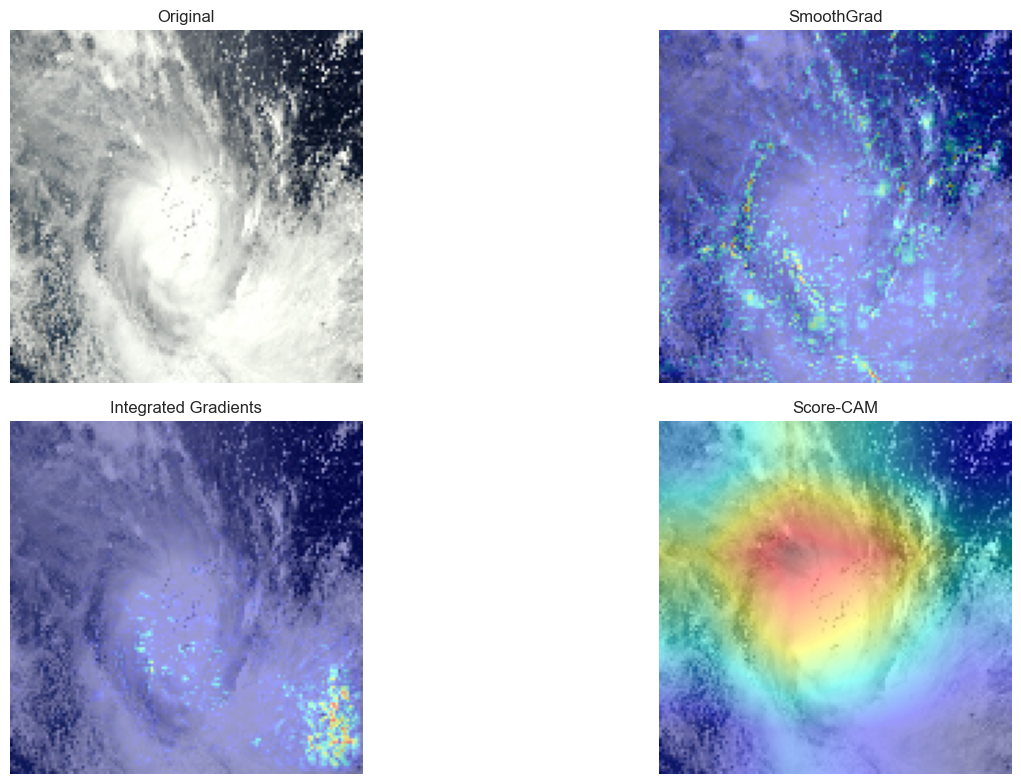

In [124]:
plt.figure(figsize=(16, 8))

plt.subplot(2, 2, 1)
plt.title("Original")
plt.imshow(orig_uint8)
plt.axis('off')

plt.subplot(2, 2, 2)
plt.title("SmoothGrad")
plt.imshow(overlay_sg)
plt.axis('off')

plt.subplot(2, 2, 3)
plt.title("Integrated Gradients")
plt.imshow(overlay_ig)
plt.axis('off')

plt.subplot(2, 2, 4)
plt.title("Score-CAM")
plt.imshow(overlay_sc)
plt.axis('off')

plt.tight_layout()
plt.show()